In [1]:
# LandownerAntelope
import tabula
import pandas as pd
import requests
import io
import numpy as np
from publictrust.wildlife import parse_pdf_to_dataframe, create_interactive_map
import geopandas as gpd
from pathlib import Path



## READ THE WGFD 2025 RESIDENT LANDOWNER ANTELOPE TAG QUOTA DATA

In [2]:

landownertags2025_url = "https://wgfd.wyo.gov/media/32685/download?inline" # 2025 Resident Landowner Antelope Tag Quotas PDF

# Get the DataFrame
landowner_tags = parse_pdf_to_dataframe(landownertags2025_url)

if not landowner_tags.empty:
    # Determine percentage of tags allocated to the landowner
    landowner_tags['pct_landowner'] = landowner_tags['Issued']/landowner_tags['Quota'] * 100
    ls_tag_dist = []
    for i, row in landowner_tags.iterrows():
        ls_tag_dist.append(f"{row['Issued']} of {row['Quota']}")
    landowner_tags['landowner_tags_per_total'] = ls_tag_dist
else:
    print("PROBLEM WITH READING DATA FROM THE PDF FILE. CANNOT PROCEED!")

Successfully parsed PDF and created DataFrame.


In [6]:
# Review summaries of landowner & resident quota data used in the maps:
print(landowner_tags)

   Hunt_Area Type   Description  Quota  Issued  PP  Applicants  pct_landowner  \
0          1    1  ANY ANTELOPE    320       1   0           0       0.312500   
1          2    1  ANY ANTELOPE    120       3   0           0       2.500000   
2          3    1  ANY ANTELOPE    180       1   0           0       0.555556   
3          4    1  ANY ANTELOPE     80       3   0           0       3.750000   
4          5    1  ANY ANTELOPE    100      24   0           0      24.000000   
..       ...  ...           ...    ...     ...  ..         ...            ...   
35       111    1  ANY ANTELOPE    120       5   0           0       4.166667   
36       112    1  ANY ANTELOPE     40       5   0           0      12.500000   
37       113    1  ANY ANTELOPE     60       0   0           0       0.000000   
38       113    2  ANY ANTELOPE     60       0   0           0       0.000000   
39       114    1  ANY ANTELOPE     40       2   0           0       5.000000   

   landowner_tags_per_total

## Visualize the distribution of resident landowner tags in 2025
How many tags went to landowners across all limited quota hunt areas?
The following plots depict
1) The distribution of all tag types
2) The distribution of type 1 tags
3) The distribution of type 2 tags

Text(0, 0.5, 'Total Hunt Areas')

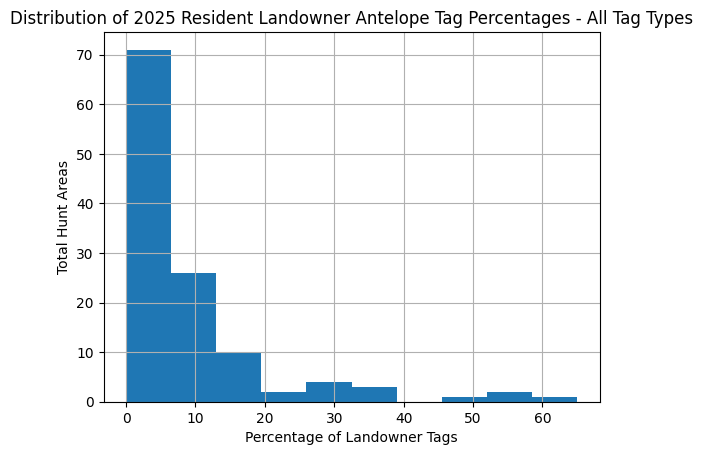

In [10]:
ax = landowner_tags['pct_landowner'].hist()
# Set the title and labels
ax.set_title("Distribution of 2025 Resident Landowner Antelope Tag Percentages - All Tag Types")
ax.set_xlabel("Percentage of Landowner Tags")
ax.set_ylabel("Total Hunt Areas")

Text(0, 0.5, 'Total Hunt Areas')

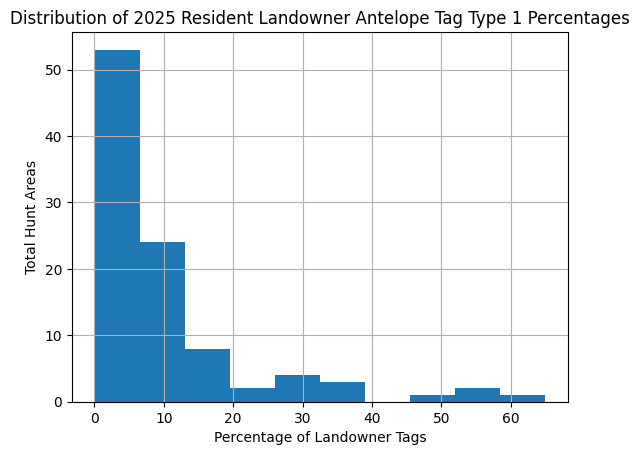

In [8]:
type1_landowner_tags = landowner_tags[landowner_tags['Type']=='1']
# Capture the axes object returned by the plot
ax = type1_landowner_tags['pct_landowner'].hist()

# Set the title and labels
ax.set_title("Distribution of 2025 Resident Landowner Antelope Tag Type 1 Percentages")
ax.set_xlabel("Percentage of Landowner Tags")
ax.set_ylabel("Total Hunt Areas")

Text(0, 0.5, 'Total Hunt Areas')

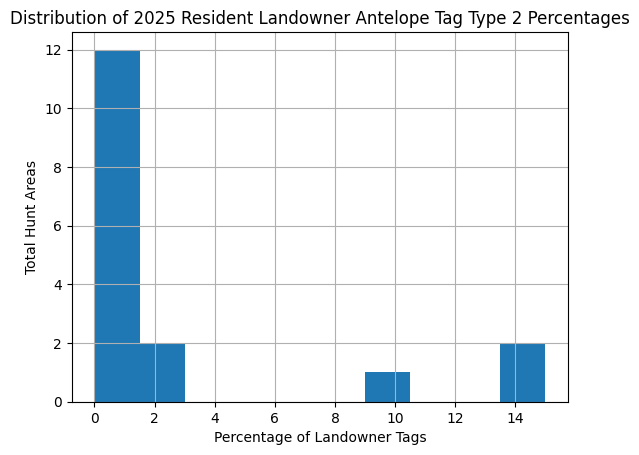

In [9]:
type2_landowner_tags = landowner_tags[landowner_tags['Type']=='2']
ax = type2_landowner_tags['pct_landowner'].hist()
# Set the title and labels
ax.set_title("Distribution of 2025 Resident Landowner Antelope Tag Type 2 Percentages")
ax.set_xlabel("Percentage of Landowner Tags")
ax.set_ylabel("Total Hunt Areas")

## MAKE MAPS

In [3]:
# Read in the Wyoming G&F Elk Hunt Areas Map
gdf_ha = gpd.read_file("~/Documents/personal/BHA/data_in/gpkg/AntelopeHuntAreas_3598308985996556140.gpkg")
gdf_ha['HUNTAREA'] = gdf_ha['HUNTAREA'].astype(str).str.replace(".0","")




In [4]:
# Combine map data with the landowner tags data
gdf_ha_cmbo = gdf_ha.merge(landowner_tags,left_on='HUNTAREA', right_on='Hunt_Area')
gdf_cmbo_type1 = gdf_ha_cmbo[gdf_ha_cmbo['Type']=='1'] # Filter to the type 1 tags

In [5]:
create_interactive_map(gdf=gdf_cmbo_type1, output_html = "~/Documents/personal/BHA/data_out/antelope2025_landowner_type1_bha.html", map_title = '2025 Type 1 Resident Landowner Antelope Tag Allocations',img_path = "~/Documents/personal/BHA/data_in/BHALOGOBLACK.clear.png")

Reprojecting data to WGS84 (EPSG:4326)...
Adding polygons and hover interactions...


/Users/guylitt/git/public_trust_wildlife/publictrust/wildlife.py:128: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_lat = gdf.geometry.centroid.y.mean()
/Users/guylitt/git/public_trust_wildlife/publictrust/wildlife.py:129: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_lon = gdf.geometry.centroid.x.mean()


Adding labels...
Map successfully generated: /Users/guylitt/Documents/personal/BHA/data_out/antelope2025_landowner_type1_bha.html
